# LINEARITY ANALYSIS

In [1]:
from src.system_discovery import SystemDiscovery, discoverNetwork
import src.constants as cn
from src.biomodels_iterator import BiomodelsIterator
from src.timecourse import Timecourse
from src.model import Model

import collections
import os
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import sbmlnetwork as sb
import tellurium as te
from typing import Optional

# Helpers

In [2]:
def checkFit(model_num: int, poly_degree=1, threshold=0.1, end_time: Optional[float]=None, num_point:int=100):
    print(F"Poly_degree: {poly_degree}, threshold: {threshold}")
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, end_time=end_time, num_point=num_point)
    timecourse.plot()
    timecourse.timecourse_df
    sd = discoverNetwork(timecourse.timecourse_df, poly_degree=poly_degree, threshold=threshold)

In [3]:
def plotValueCDF(values, title: str="", xlabel: str = "ordinate", is_plot: bool = True):
    sorted = np.sort(values)
    length = len(sorted)
    yv = np.array(range(length))/length
    plt.plot(sorted, yv)
    plt.xlabel(xlabel)
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()


In [4]:
def plotCDF(evaluate_df: pd.DataFrame, column: str, title: str = "", is_plot: bool = True):
    list_strs = [v for v in evaluate_df[column] if isinstance(v, str)]
    if len(list_strs) > 0:
        values = []
        [values.extend(eval(v)) for v in list_strs]
        value_arr = np.array(values)
    else:
        value_arr = evaluate_df[column].values
    sorted_r2 = np.sort(value_arr)
    length = len(sorted_r2)
    yv = np.array(range(length))/length
    plt.plot(sorted_r2, yv)
    plt.xlabel("r-squared")
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()

#plotCDF("deg1_values", is_plot=False)
print("OK!")

OK!


# Detailed Analysis

## BioModels 8

Poly_degree: 1, threshold: 0.1

dC/dt = 10.084 * C + -0.157 * M + -6.055 * Y + 6.210 * Z
dX/dt = -28638239361.692 * C + 413037671.195 * M + 17138712805.083 * Y + -17138712804.800 * Z
dM/dt = -650.718 * C + 5.887 * M + 390.786 * Y + -390.786 * Z
dY/dt = 12.003 * C + -0.185 * M + -7.219 * Y + 7.421 * Z
dZ/dt = -10.325 * C + 0.159 * M + 6.209 * Y + -6.266 * Z
R² on time derivatives per species:
  C: 0.997736
  X: 0.079790
  M: 0.984961
  Y: 0.998549
  Z: 0.996156

R² on simulated trajectories per species:
  C: 1.000000
  X: 0.000000
  M: 0.981162
  Y: 1.000000
  Z: 1.000000



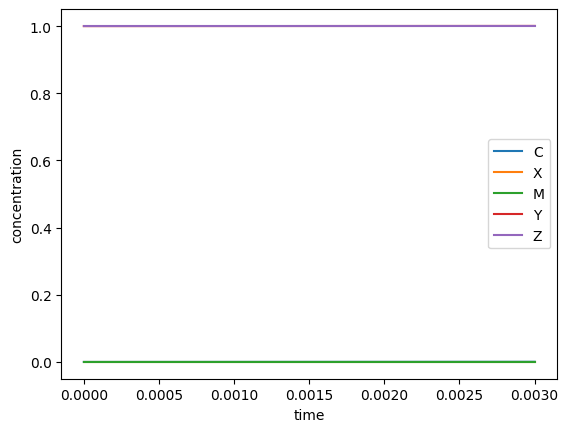

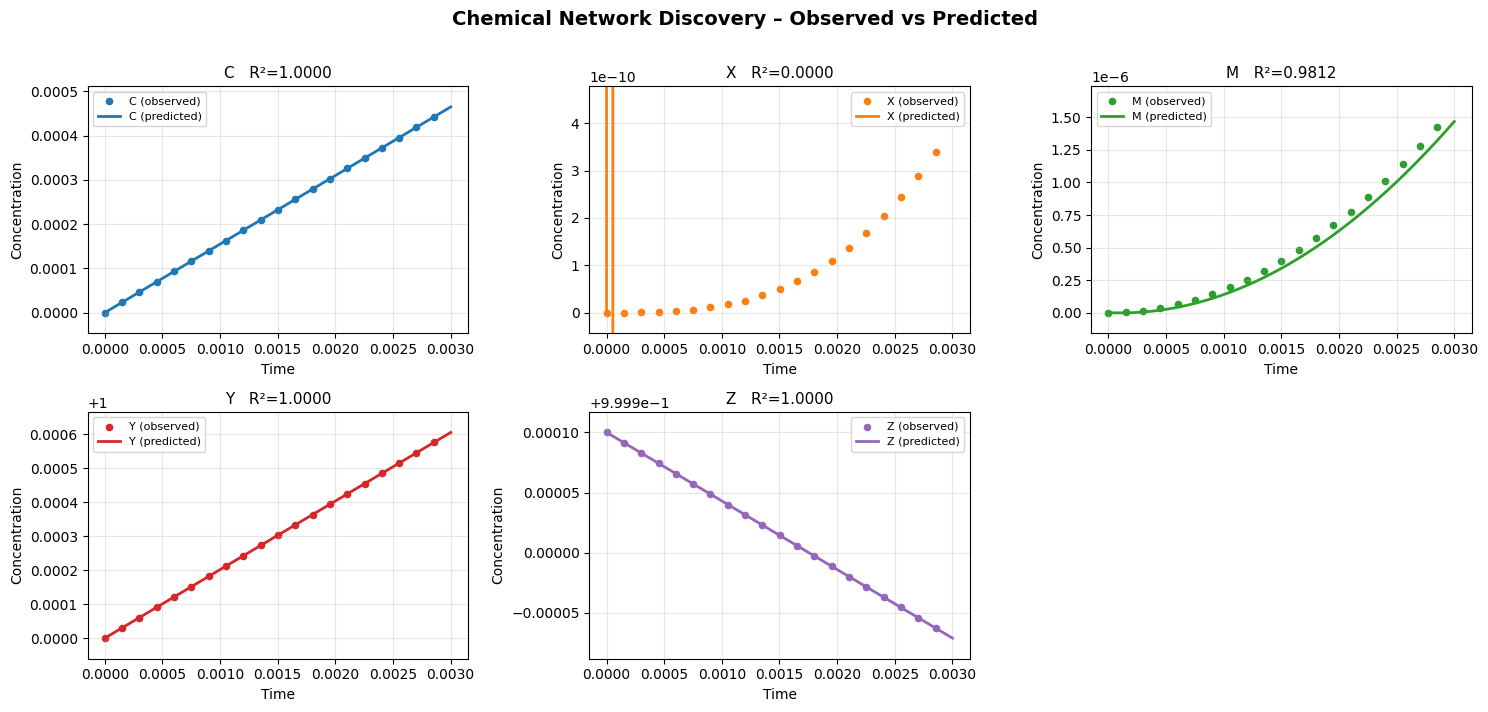

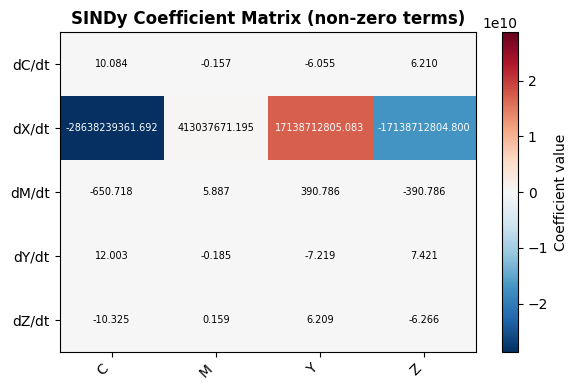

In [5]:
checkFit(8, num_point=1000)

## BioModels 206

Poly_degree: 1, threshold: 0.001

ds1/dt = 860.498 + -144.967 * s1 + -128.641 * at + -599.616 * s2 + 1657.272 * s3 + -1109.561 * na + -119.922 * s4 + 263.551 * s5 + -3250.159 * s6 + 21329.012 * s6o
dat/dt = 1959.472 + -248.139 * s1 + -276.827 * at + -1091.835 * s2 + 2894.156 * s3 + -2793.299 * na + -156.038 * s4 + 482.043 * s5 + -2530.419 * s6 + 34493.152 * s6o
ds2/dt = -808.308 + 143.953 * s1 + 128.168 * at + 589.078 * s2 + -1664.619 * s3 + 1105.913 * na + 123.988 * s4 + -262.283 * s5 + 3209.265 * s6 + -21336.057 * s6o
ds3/dt = -137.133 + -2.632 * s1 + 1.555 * at + 10.326 * s2 + -12.219 * s3 + 221.749 * na + -13.460 * s4 + 0.821 * s5 + -759.293 * s6 + 768.085 * s6o
dna/dt = -24.278 + -0.103 * s1 + 3.261 * at + -1.709 * s2 + 34.093 * s3 + 16.121 * na + -8.160 * s4 + 1.438 * s5 + -373.212 * s6 + 796.562 * s6o
ds4/dt = -181.647 + -32.427 * s1 + -11.394 * at + -95.265 * s2 + 460.677 * s3 + 346.424 * na + -92.427 * s4 + 44.844 * s5 + -2751.081 * s6 + 6789.783 * s6o
ds5/dt = 269.540 + 34.55

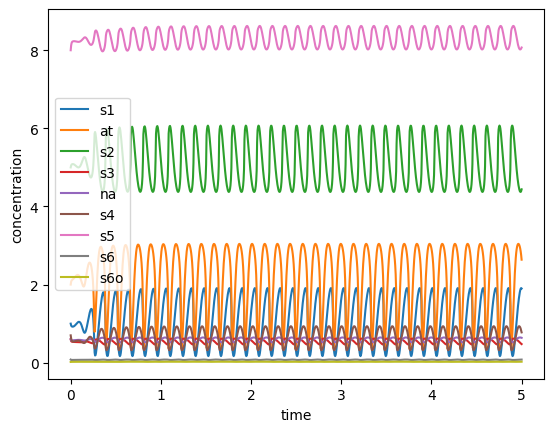

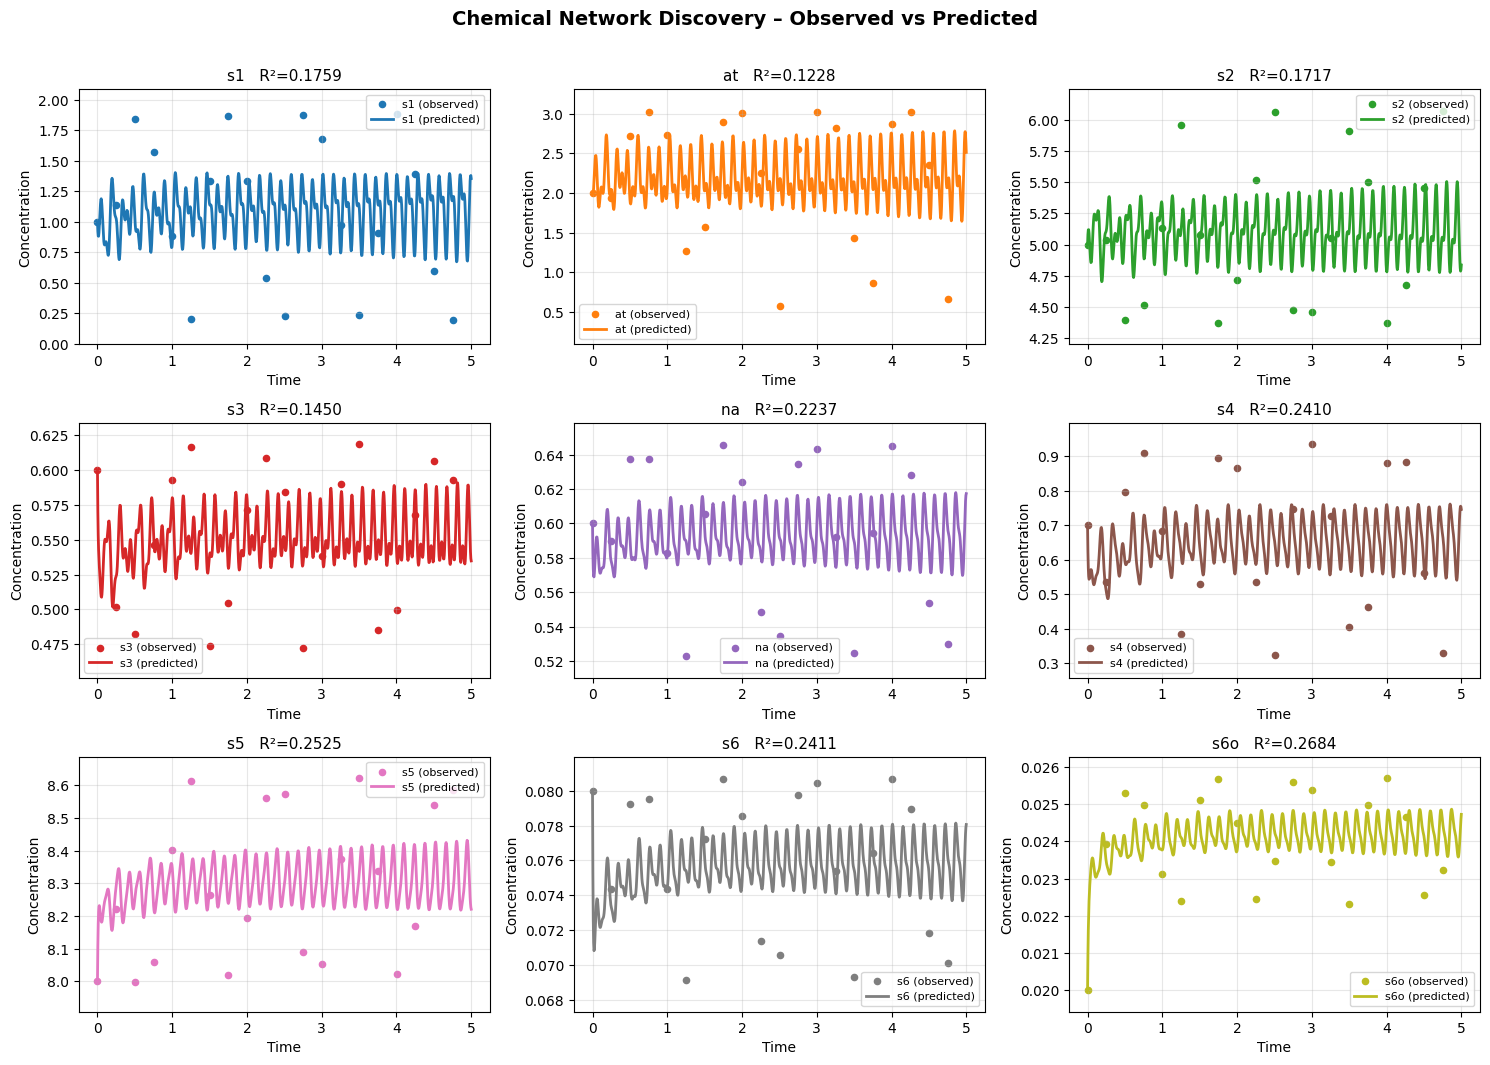

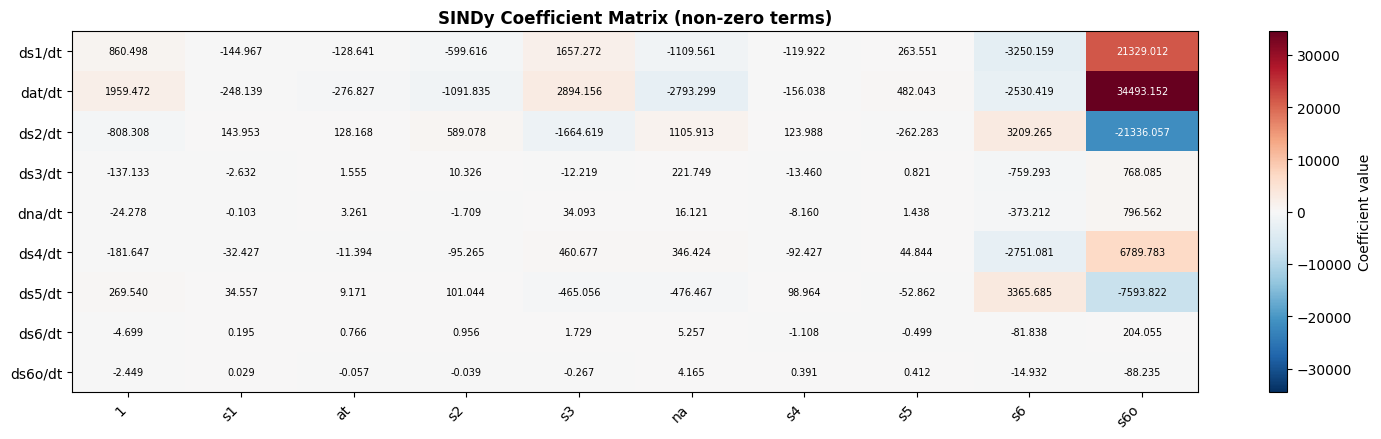

In [6]:
checkFit(206, threshold=0.001, poly_degree=1, num_point=1000, end_time=5)

## BioModels 181

Poly_degree: 1, threshold: 0.1

dT1/dt = -37.634 + 0.980 * T1 + 5.328 * T2 + 1.449 * T3 + 2.493 * C1 + 4.347 * C2 + 9.967 * C3
dT2/dt = 14.637 + -0.564 * T1 + -2.826 * T2 + -0.506 * T3 + -0.743 * C1 + -1.394 * C2 + -4.303 * C3
dT3/dt = 34.708 + -1.413 * T1 + -4.550 * T2 + -2.582 * T3 + -1.670 * C1 + -3.871 * C2 + -11.015 * C3
dC1/dt = 133.803 + -7.405 * T1 + -16.649 * T2 + -2.158 * T3 + -8.666 * C1 + -15.617 * C2 + -29.828 * C3
dC2/dt = 32.360 + -1.386 * T1 + -3.985 * T2 + -1.120 * T3 + -2.128 * C1 + -3.900 * C2 + -7.521 * C3
dC3/dt = -33.835 + 1.707 * T1 + 4.571 * T2 + 0.887 * T3 + 2.115 * C1 + 3.864 * C2 + 7.822 * C3
R² on time derivatives per species:
  T1: 1.000000
  T2: 1.000000
  T3: 1.000000
  C1: 1.000000
  C2: 1.000000
  C3: 1.000000

R² on simulated trajectories per species:
  T1: 1.000000
  T2: 1.000000
  T3: 1.000000
  C1: 1.000000
  C2: 1.000000
  C3: 1.000000



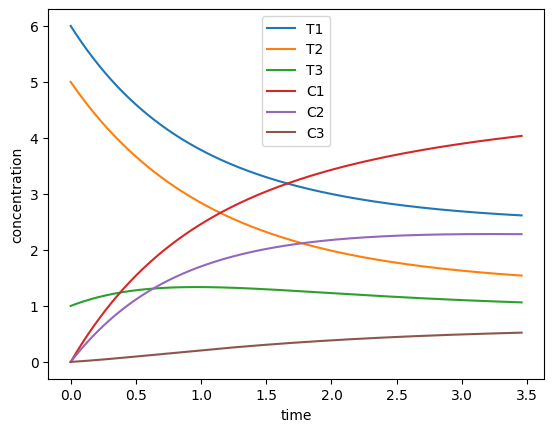

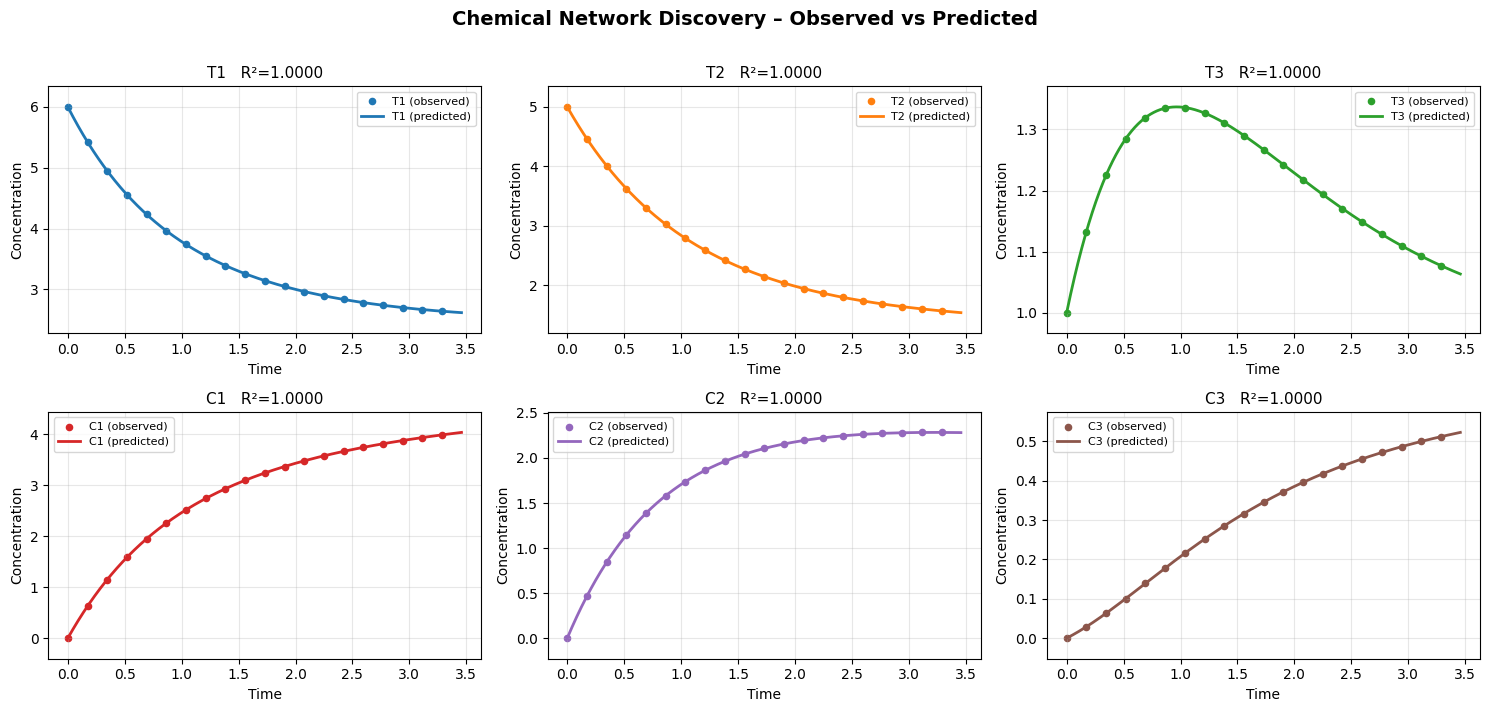

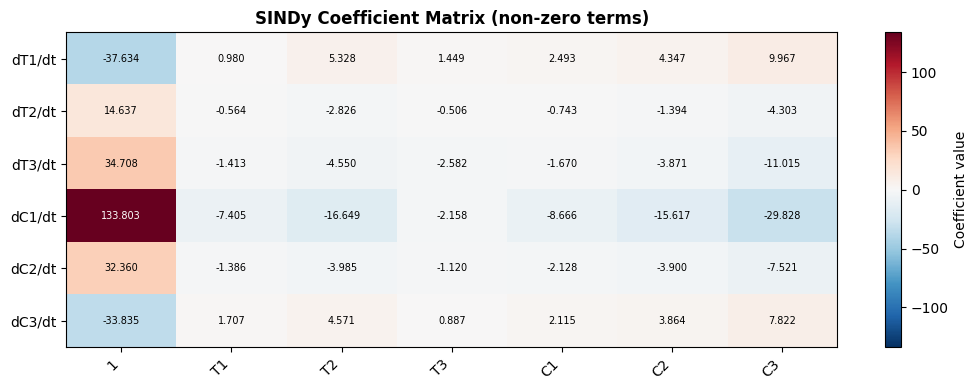

In [7]:
checkFit(181, threshold=0.1, poly_degree=1, num_point=1000)

# Analysis of fits

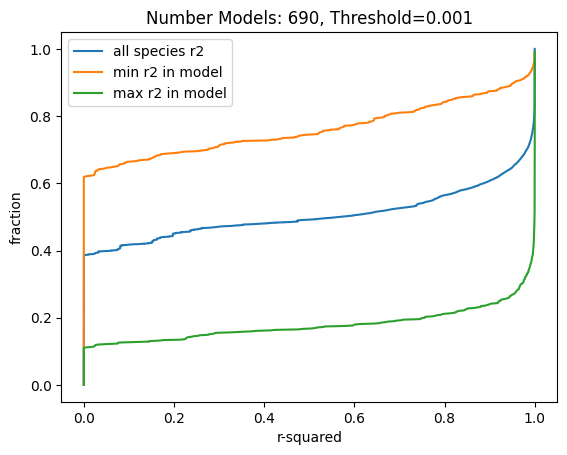

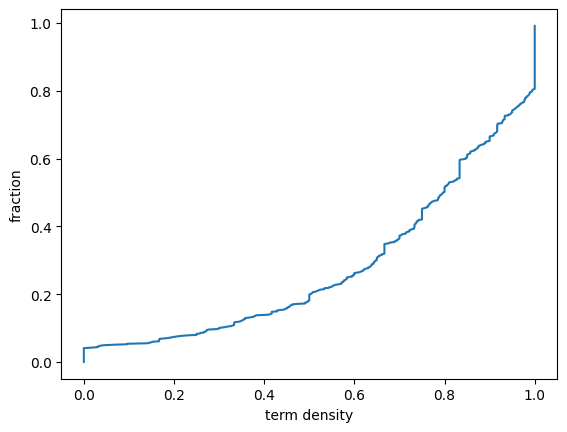

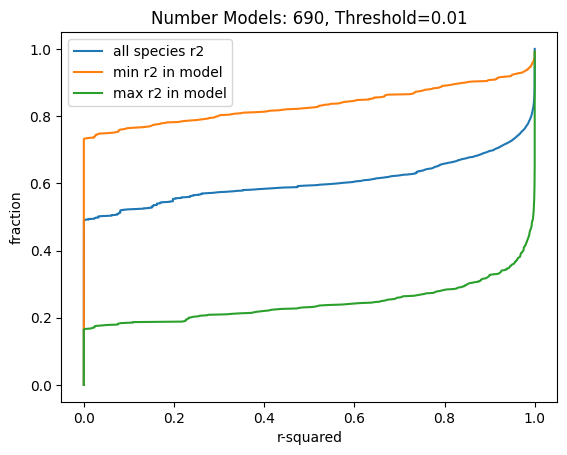

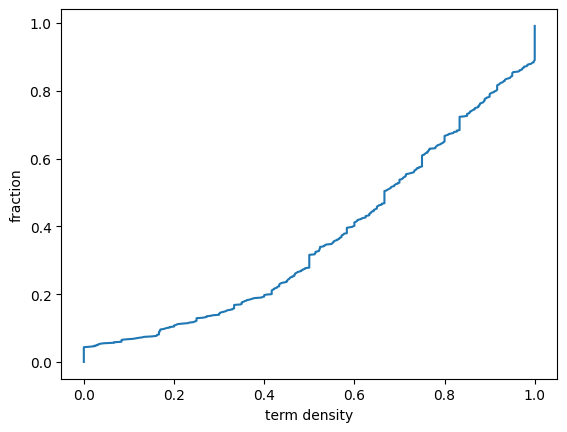

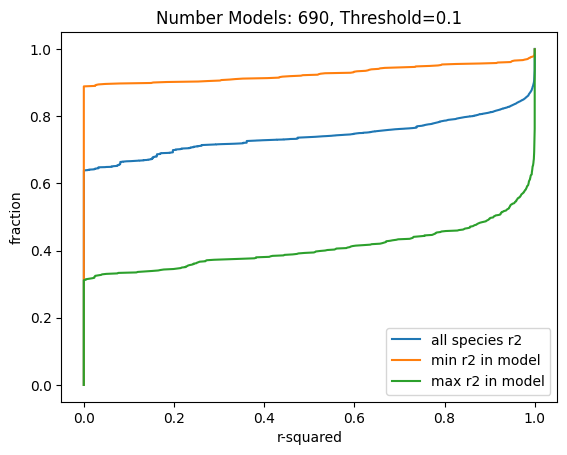

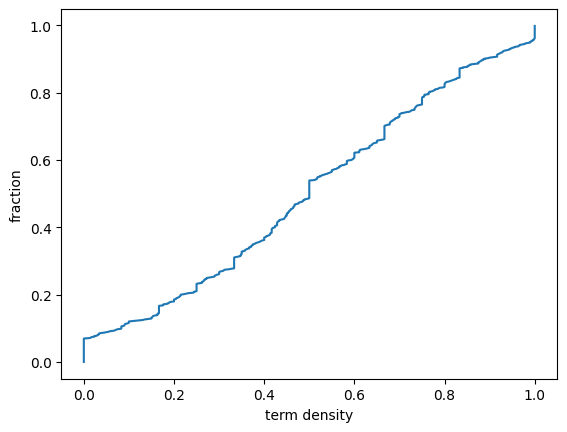

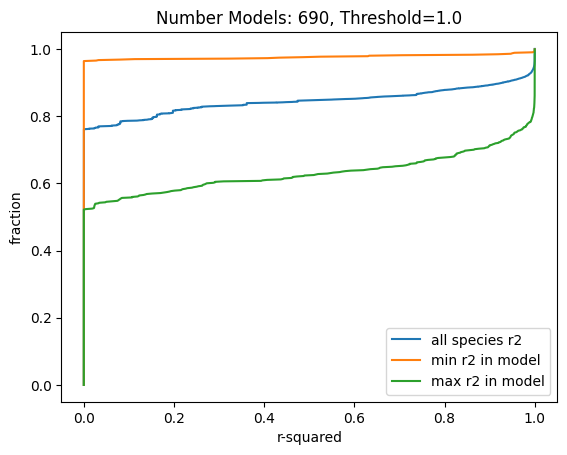

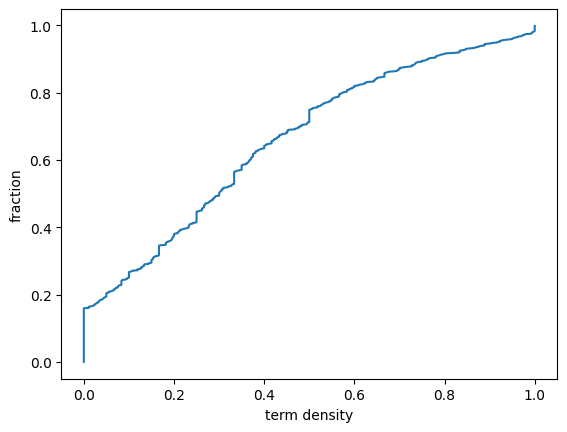

In [9]:
for threshold in ["0.001", "0.01", "0.1", "1.0"]:
    path = os.path.join(cn.DATA_DIR, "evaluate_monomial_models-" + threshold + ".csv")
    df = pd.read_csv(path)
    df["deg1_term_density"] = df["deg1_num_nonzero_term"]/(df["num_species"]*(df["num_species"] + 1))
    plt.figure()
    plotCDF(df, "deg1_values", title=f"Number Models: {len(df)}, Threshold={threshold}")
    plotCDF(df, "deg1_min")
    plotCDF(df, "deg1_max")
    _ = plt.legend(["all species r2", "min r2 in model", "max r2 in model"])
    _ = plt.title(f"Number Models: {len(df)}, Threshold={threshold}")
    plt.figure()
    plotValueCDF(df["deg1_term_density"].values, xlabel="term density")

# Species